In [2]:
import pandas as pd

# 1.Load the dataset
df = pd.read_csv("listings.csv.gz")

# 2.Check basic dimensions
print(f"Total rows (listings): {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

# 3. Calculate missing values for the 'price' column before cleaning
missing_price_count = df['price'].isnull().sum()
total_rows = len(df)
missing_price_percentage = (missing_price_count / total_rows) * 100

print(f"Missing price count: {missing_price_count}")
print(f"Missing price percentage: {missing_price_percentage:.2f}%")

# 4. Clean the price column (removes '$' and ',' then converts to float)
df['price_clean'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

# 5. Check summary statistics of the cleaned price
print("\nCleaned Price Summary Statistics:")
print(df['price_clean'].describe())

Total rows (listings): 77679
Total columns: 90
Missing price count: 29277
Missing price percentage: 37.69%

Cleaned Price Summary Statistics:
count    48402.000000
mean       321.230271
std        832.551387
min          3.200000
25%        131.330000
50%        205.500000
75%        342.000000
max      97003.050000
Name: price_clean, dtype: float64


In [3]:
df = df.dropna(subset=['price_clean']).copy()
print(f"Rows remaining after dropping missing price: {len(df)}")

Rows remaining after dropping missing price: 48402


In [4]:
import numpy as np
df['log_price'] = np.log1p(df['price_clean'])

In [5]:
# Check how extreme the top end really is
print(df['price_clean'].quantile([0.95, 0.99, 0.995, 0.999]))

# Cap at 99th percentile (adjust after seeing the quantiles above)
upper_cap = df['price_clean'].quantile(0.99)
df = df[df['price_clean'] <= upper_cap]

# Also drop nonsensical low prices (e.g., $0 or near-$0 listings)
df = df[df['price_clean'] > 0]

print(f"Rows remaining after outlier removal: {len(df)}")

0.950     842.3925
0.990    1874.9800
0.995    2974.9375
0.999    8000.0000
Name: price_clean, dtype: float64
Rows remaining after outlier removal: 47917


In [6]:
import numpy as np
df['log_price'] = np.log1p(df['price_clean'])
print(df['log_price'].describe())

count    47917.000000
mean         5.341327
std          0.762919
min          1.435085
25%          4.881437
50%          5.323010
75%          5.814131
max          7.535830
Name: log_price, dtype: float64


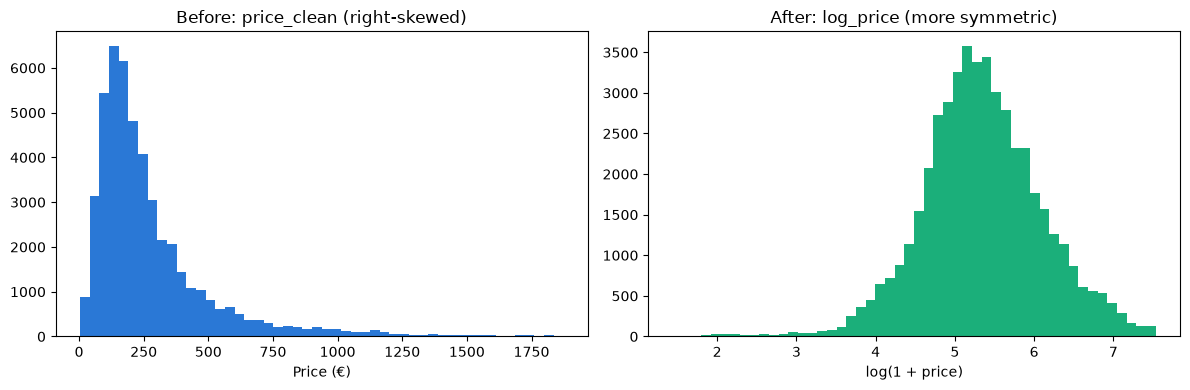

count    47917.000000
mean         5.341327
std          0.762919
min          1.435085
25%          4.881437
50%          5.323010
75%          5.814131
max          7.535830
Name: log_price, dtype: float64


In [7]:
import numpy as np
import matplotlib.pyplot as plt

df['log_price'] = np.log1p(df['price_clean'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price_clean'], bins=50, color='#2a78d6')
axes[0].set_title('Before: price_clean (right-skewed)')
axes[0].set_xlabel('Price (€)')

axes[1].hist(df['log_price'], bins=50, color='#1baf7a')
axes[1].set_title('After: log_price (more symmetric)')
axes[1].set_xlabel('log(1 + price)')

plt.tight_layout()
plt.savefig('price_distribution_comparison.png', dpi=150)
plt.show()

print(df['log_price'].describe())

In [8]:
key_cols = ['bedrooms', 'bathrooms', 'beds', 'accommodates',
            'review_scores_rating', 'reviews_per_month',
            'neighbourhood_cleansed', 'room_type', 'amenities']

missing_summary = df[key_cols].isnull().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(2)

print(pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct}))

                        missing_count  missing_pct
review_scores_rating             8069        16.84
reviews_per_month                8069        16.84
bedrooms                         7743        16.16
bathrooms                        5820        12.15
beds                             4344         9.07
accommodates                        0         0.00
neighbourhood_cleansed              0         0.00
room_type                           0         0.00
amenities                           0         0.00


In [9]:
print(df[df['review_scores_rating'].isnull()]['number_of_reviews'].describe())

count    8069.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: number_of_reviews, dtype: float64


In [10]:
# Flag that tells the model "this listing has no review history"
df['has_reviews'] = df['number_of_reviews'] > 0

# Fill missing scores with 0 (or median of a *default* group) since there's no data yet
df['review_scores_rating'] = df['review_scores_rating'].fillna(0)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [11]:
# Impute bedrooms/beds/bathrooms based on similar-sized listings (grouped median)
for col in ['bedrooms', 'beds', 'bathrooms']:
    df[col] = df.groupby('accommodates')[col].transform(lambda x: x.fillna(x.median()))

# Catch any remaining NaNs (e.g., rare accommodates values with no data at all)
for col in ['bedrooms', 'beds', 'bathrooms']:
    df[col] = df[col].fillna(df[col].median())

In [12]:
print(df[key_cols].isnull().sum())

bedrooms                  0
bathrooms                 0
beds                      0
accommodates              0
review_scores_rating      0
reviews_per_month         0
neighbourhood_cleansed    0
room_type                 0
amenities                 0
dtype: int64


In [13]:
print(df['room_type'].value_counts())

room_type
Entire home/apt    42719
Private room        4776
Hotel room           309
Shared room          113
Name: count, dtype: int64


In [14]:
df = pd.get_dummies(df, columns=['room_type'], prefix='room', drop_first=True)

In [15]:
print(df['neighbourhood_cleansed'].nunique())

20


In [16]:
df = pd.get_dummies(df, columns=['neighbourhood_cleansed'], prefix='nbhd', drop_first=True)

In [19]:
print([c for c in df.columns if 'neighb' in c.lower() or 'nbhd' in c.lower()])

['neighborhood_overview', 'host_neighbourhood', 'neighbourhood', 'neighbourhood_group_cleansed', 'nbhd_Bourse', 'nbhd_Buttes-Chaumont', 'nbhd_Buttes-Montmartre', 'nbhd_Entrepôt', 'nbhd_Gobelins', 'nbhd_Hôtel-de-Ville', 'nbhd_Louvre', 'nbhd_Luxembourg', 'nbhd_Ménilmontant', 'nbhd_Observatoire', 'nbhd_Opéra', 'nbhd_Palais-Bourbon', 'nbhd_Panthéon', 'nbhd_Passy', 'nbhd_Popincourt', 'nbhd_Reuilly', 'nbhd_Temple', 'nbhd_Vaugirard', 'nbhd_Élysée']


In [20]:
print(df.shape)
print([c for c in df.columns if c.startswith('nbhd_')])

(47917, 113)
['nbhd_Bourse', 'nbhd_Buttes-Chaumont', 'nbhd_Buttes-Montmartre', 'nbhd_Entrepôt', 'nbhd_Gobelins', 'nbhd_Hôtel-de-Ville', 'nbhd_Louvre', 'nbhd_Luxembourg', 'nbhd_Ménilmontant', 'nbhd_Observatoire', 'nbhd_Opéra', 'nbhd_Palais-Bourbon', 'nbhd_Panthéon', 'nbhd_Passy', 'nbhd_Popincourt', 'nbhd_Reuilly', 'nbhd_Temple', 'nbhd_Vaugirard', 'nbhd_Élysée']


In [22]:
import ast

if 'amenities' in df.columns:
    def safe_parse(x):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []

    df['amenities_list'] = df['amenities'].apply(safe_parse)
    df['amenity_count'] = df['amenities_list'].apply(len)
    df['has_wifi'] = df['amenities_list'].apply(lambda lst: any('wifi' in a.lower() for a in lst))
    df['has_kitchen'] = df['amenities_list'].apply(lambda lst: any('kitchen' in a.lower() for a in lst))
    df['has_ac'] = df['amenities_list'].apply(lambda lst: any('air conditioning' in a.lower() for a in lst))

    df = df.drop(columns=['amenities', 'amenities_list'])
else:
    print("Already encoded")

In [23]:
print(df.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'm

In [24]:
drop_cols = [
    # IDs, URLs, scrape metadata — no predictive value
    'id', 'listing_url', 'scrape_id', 'last_scraped', 'source',
    'name', 'description', 'neighborhood_overview', 'picture_url',
    'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
    'host_thumbnail_url', 'host_picture_url', 'host_about', 'host_location',

    # Leakage risk — quotes derived from live price
    'price_quote_checkin_date', 'price_quote_checkout_date',
    'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw',

    # Redundant location text (already one-hot encoded as nbhd_*)
    'neighbourhood', 'neighbourhood_group_cleansed', 'host_neighbourhood',

    # Redundant/raw versions (already have cleaned numeric equivalents)
    'bathrooms_text', 'price', 'host_since',

    # Rarely reliable / high-missingness / low signal for a first model
    'calendar_updated', 'calendar_last_scraped', 'license',
    'host_verifications', 'first_review', 'last_review',
]

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(df_model.shape)

(47917, 81)


In [25]:
print(df['property_type'].nunique())

56


In [26]:
df_model = df_model.drop(columns=['property_type'])

In [27]:
print(df['host_response_time'].value_counts(dropna=False))

host_response_time
NaN    47917
Name: count, dtype: int64


In [28]:
df_model = df_model.drop(columns=['host_response_time'])

In [29]:
print(df['host_response_rate'].isnull().sum())
print(df['host_acceptance_rate'].isnull().sum())

47917
47917


In [30]:
import numpy as np
import pandas as pd

# 1. Drop property_type (Option A — rely on room_type instead)
if 'property_type' in df_model.columns:
    df_model = df_model.drop(columns=['property_type'])

# 2. Drop host_response_time (100% missing)
if 'host_response_time' in df_model.columns:
    df_model = df_model.drop(columns=['host_response_time'])

# 3. Convert t/f boolean columns to 0/1
bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
             'instant_bookable', 'has_availability']
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({'t': 1, 'f': 0})
        df_model[col] = df_model[col].fillna(0)

# 4. Convert percentage-string columns to numeric (drop if fully/mostly missing)
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_model.columns:
        if df[col].isnull().mean() > 0.9:
            df_model = df_model.drop(columns=[col])
        else:
            df_model[col] = df_model[col].astype(str).str.replace('%', '').astype(float)
            df_model[col] = df_model[col].fillna(df_model[col].median())

print(df_model.shape)
print(df_model.isnull().sum().sum(), "total remaining missing values")

(47917, 77)
97446 total remaining missing values


In [31]:
missing = df_model.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print("\nAs percentage:")
print((missing / len(df_model) * 100).round(2))

host_total_listings_count      47917
review_scores_checkin           8069
review_scores_accuracy          8069
review_scores_cleanliness       8069
review_scores_location          8069
review_scores_communication     8069
review_scores_value             8069
hosts_time_as_user_years         223
hosts_time_as_host_months        223
hosts_time_as_host_years         223
hosts_time_as_user_months        223
host_listings_count              223
dtype: int64

As percentage:
host_total_listings_count      100.00
review_scores_checkin           16.84
review_scores_accuracy          16.84
review_scores_cleanliness       16.84
review_scores_location          16.84
review_scores_communication     16.84
review_scores_value             16.84
hosts_time_as_user_years         0.47
hosts_time_as_host_months        0.47
hosts_time_as_host_years         0.47
hosts_time_as_user_months        0.47
host_listings_count              0.47
dtype: float64


In [32]:
df_model = df_model.drop(columns=['host_total_listings_count'])

In [33]:
review_subscores = ['review_scores_checkin', 'review_scores_accuracy',
                     'review_scores_cleanliness', 'review_scores_location',
                     'review_scores_communication', 'review_scores_value']
for col in review_subscores:
    df_model[col] = df_model[col].fillna(0)

In [34]:
small_missing = ['hosts_time_as_user_years', 'hosts_time_as_host_months',
                  'hosts_time_as_host_years', 'hosts_time_as_user_months',
                  'host_listings_count']
for col in small_missing:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

In [35]:
print(df_model.shape)
print(df_model.isnull().sum().sum(), "total remaining missing values")

(47917, 76)
0 total remaining missing values


In [36]:
from sklearn.model_selection import train_test_split

# Drop price_clean too — log_price is your actual target now
X = df_model.drop(columns=['price_clean', 'log_price'])
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (38333, 74)
Test shape: (9584, 74)


In [37]:
from sklearn.preprocessing import RobustScaler

numeric_cols = ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'amenity_count',
                 'minimum_nights', 'maximum_nights', 'availability_365',
                 'number_of_reviews', 'reviews_per_month']
numeric_cols = [c for c in numeric_cols if c in X_train.columns]

scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train_scaled[numeric_cols].describe())

       accommodates      bedrooms     bathrooms          beds  amenity_count  \
count  38333.000000  38333.000000  38333.000000  38333.000000   38333.000000   
mean       0.173702      0.404925      0.198497     -0.141132      -0.022701   
std        0.889749      0.774488      0.521532      1.129704       0.716552   
min       -1.000000     -1.000000     -0.500000     -1.000000      -1.578947   
25%       -0.500000      0.000000      0.000000     -1.000000      -0.526316   
50%        0.000000      0.000000      0.000000      0.000000       0.000000   
75%        0.500000      1.000000      0.000000      0.000000       0.473684   
max        6.500000     32.000000     32.500000     28.000000       4.263158   

       minimum_nights  maximum_nights  availability_365  number_of_reviews  \
count    38333.000000    3.833300e+04      38333.000000       38333.000000   
mean         2.089123    1.636748e+02         -0.035643           0.598782   
std          9.068902    2.264447e+04        

In [39]:
print(df_model['maximum_nights'].describe())
print(df_model['maximum_nights'].sort_values(ascending=False).head(10))

count    4.791700e+04
mean     1.348879e+05
std      1.699169e+07
min      1.000000e+00
25%      4.500000e+01
50%      3.650000e+02
75%      7.300000e+02
max      2.147484e+09
Name: maximum_nights, dtype: float64
21397    2147483647
21398    2147483647
21399    2147483647
54522          1125
30             1125
43             1125
25735          1125
54642          1125
25684          1125
25682          1125
Name: maximum_nights, dtype: int64


In [40]:
df_model['maximum_nights'] = df_model['maximum_nights'].clip(upper=1125)

# Verify the fix
print(df_model['maximum_nights'].describe())

count    47917.000000
mean       437.734291
std        412.021210
min          1.000000
25%         45.000000
50%        365.000000
75%        730.000000
max       1125.000000
Name: maximum_nights, dtype: float64


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df_model.drop(columns=['price_clean', 'log_price'])
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'amenity_count',
                 'minimum_nights', 'maximum_nights', 'availability_365',
                 'number_of_reviews', 'reviews_per_month']
numeric_cols = [c for c in numeric_cols if c in X_train.columns]

scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train_scaled[numeric_cols].describe())

       accommodates      bedrooms     bathrooms          beds  amenity_count  \
count  38333.000000  38333.000000  38333.000000  38333.000000   38333.000000   
mean       0.173702      0.404925      0.198497     -0.141132      -0.022701   
std        0.889749      0.774488      0.521532      1.129704       0.716552   
min       -1.000000     -1.000000     -0.500000     -1.000000      -1.578947   
25%       -0.500000      0.000000      0.000000     -1.000000      -0.526316   
50%        0.000000      0.000000      0.000000      0.000000       0.000000   
75%        0.500000      1.000000      0.000000      0.000000       0.473684   
max        6.500000     32.000000     32.500000     28.000000       4.263158   

       minimum_nights  maximum_nights  availability_365  number_of_reviews  \
count    38333.000000    38333.000000      38333.000000       38333.000000   
mean         2.089123        0.107622         -0.035643           0.598782   
std          9.068902        0.601580        

In [42]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [43]:
import os
os.makedirs('data/processed', exist_ok=True)

X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
X_train_scaled.to_csv('data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('data/processed/X_test_scaled.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)